<a href="https://colab.research.google.com/github/joshuanelson-port/journal-entry-anomaly-detection/blob/main/journal_entry_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load Data From .xlsx and Prepare the data**

In [80]:
import pandas as pd

# load the working dataset -- the "clean" sheet with no anomaly labels in it, so we never accidentally train the model on the answer
df = pd.read_excel('journal_entries.xlsx', sheet_name='Model Input (no answer key)')

# separately load just the answer key, kept aside for grading results later
answer_key = pd.read_excel('journal_entries.xlsx', sheet_name='Journal Entries')[['entry_id', 'is_anomaly', 'anomaly_type']]

# engineered feature: how often this debit/credit account pairing occurs overall -- a low count means this is a rare combination, which is a real audit red flag
pair_counts = df.groupby(['debit_account', 'credit_account'])['entry_id'].transform('count')
df['account_pair_frequency'] = pair_counts

# engineered feature: how often this preparer has posted to this specific account -- a low count means this person doesn't normally touch this account
prep_acct_counts = df.groupby(['preparer', 'debit_account'])['entry_id'].transform('count')
df['preparer_account_frequency'] = prep_acct_counts

# engineered feature: flags entries where the same person prepared and approved
df['preparer_is_approver'] = (df['preparer'] == df['approver']).astype(int)

df.head()  # sanity check that the new columns look right before moving on

,entry_id,posting_datetime,posting_date,posting_day_of_week,posting_hour,is_weekend,debit_account,debit_account_name,credit_account,credit_account_name,amount,preparer,approver,cost_center,description,account_pair_frequency,preparer_account_frequency,preparer_is_approver
0,JE-2501,2025-10-14 10:43:00,2025-10-14,Tuesday,10,False,5020,Freight/Shipping,2010,Accounts Payable,2122.90,Preparer_H,Approver_C,CC-500,Freight/Shipping - routine entry,405,142,0
1,JE-3586,2025-06-04 15:09:00,2025-06-04,Wednesday,15,False,6030,Professional Fees,2010,Accounts Payable,1247.02,Preparer_G,Approver_D,CC-200,Professional Fees - routine entry,413,133,0
2,JE-3653,2025-03-24 16:09:00,2025-03-24,Monday,16,False,5020,Freight/Shipping,2010,Accounts Payable,921.42,Preparer_F,Approver_D,CC-400,Freight/Shipping - routine entry,405,137,0
3,JE-2055,2025-09-19 15:50:00,2025-09-19,Friday,15,False,6050,Marketing,2010,Accounts Payable,1307.23,Preparer_B,Approver_B,CC-100,Marketing - routine entry,415,128,0
4,JE-1705,2025-06-30 13:51:00,2025-06-30,Monday,13,False,6030,Professional Fees,2010,Accounts Payable,935.35,Preparer_G,Approver_B,CC-100,Professional Fees - routine entry,413,133,0


In [81]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# text/category fields -- need one-hot encoding since the model only understands numbers
categorical_features = ['debit_account', 'credit_account', 'preparer', 'approver',
                         'cost_center', 'is_weekend', 'posting_day_of_week']

# number fields -- includes the 3 engineered features from the previous cell
numeric_features = ['amount', 'posting_hour', 'account_pair_frequency', 'preparer_account_frequency', 'preparer_is_approver']

# tells sklearn which transformation to apply to which columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

# actually runs the transformation -- X is the final numeric matrix the model trains on
X = preprocessor.fit_transform(df[categorical_features + numeric_features])

**Model Train**

In [82]:
# no train/test split needed -- IsolationForest learns "normal" from the whole dataset, no labels required
model = IsolationForest(
    n_estimators=200,   # standard range (100-200) for stable scores without excessive runtime -- 5,000 rows is small enough this barely costs any time
    contamination=0.06, # matches the known 6% we planted in this synthetic dataset; on real data this would be a judgment call based on audit experience, or set by "how many flagged entries can a human actually review"
    random_state=42      # arbitrary fixed value, chosen only so results are repeatable run to run
)

model.fit(X)

IsolationForest(contamination=0.06, n_estimators=200, random_state=42)

**Model Accuracy**

Testing which contamination value to use

contamination=0.02: precision=93.0%, recall=31.0%
contamination=0.04: precision=66.5%, recall=44.3%
contamination=0.06: precision=51.7%, recall=51.7%
contamination=0.08: precision=41.8%, recall=55.7%
contamination=0.1: precision=36.4%, recall=60.7%


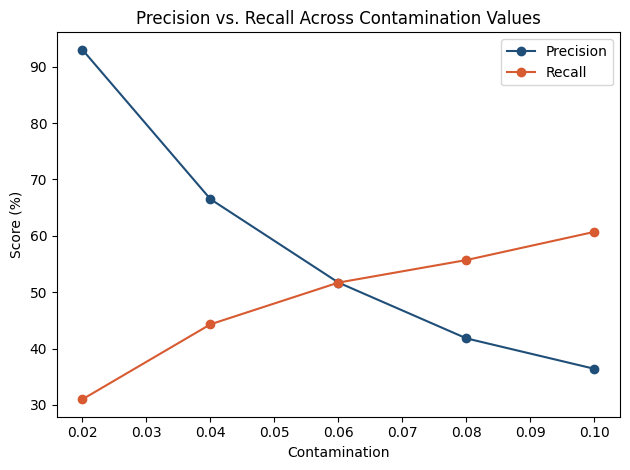

<Figure size 640x480 with 0 Axes>

In [83]:
# sweep across a few contamination values to see the precision/recall tradeoff directly, instead of guessing at a single number
sweep_results = []  # will hold one row per contamination value for the table

for c in [0.02, 0.04, 0.06, 0.08, 0.10]:
    # retrain a fresh model at each threshold -- contamination has to be set
    # before fitting, it's not something you can adjust after the fact
    m = IsolationForest(n_estimators=200, contamination=c, random_state=42)
    m.fit(X)
    pred = m.predict(X) == -1

    # same true/false positive/negative counts as before, just recalculated for this specific contamination value
    tp = ((pred == True) & (results['is_anomaly'] == True)).sum()
    fp = ((pred == True) & (results['is_anomaly'] == False)).sum()
    fn = ((pred == False) & (results['is_anomaly'] == True)).sum()

    p = tp / (tp + fp)  # precision at this threshold
    r = tp / (tp + fn)  # recall at this threshold

    print(f"contamination={c}: precision={p:.1%}, recall={r:.1%}")

    # save this row for the table below
    sweep_results.append({'contamination': c, 'precision': p, 'recall': r})

# turn the collected rows into a clean table -- easier to read than the printed
# lines above, and this is what you'd actually screenshot for the README
sweep_df = pd.DataFrame(sweep_results)
sweep_df['precision'] = (sweep_df['precision'] * 100).round(1)
sweep_df['recall'] = (sweep_df['recall'] * 100).round(1)
sweep_df

plt.plot(sweep_df['contamination'], sweep_df['precision'], marker='o', label='Precision', color='#1F4E78')
plt.plot(sweep_df['contamination'], sweep_df['recall'], marker='o', label='Recall', color='#D85A30')
plt.xlabel('Contamination')
plt.ylabel('Score (%)')
plt.title('Precision vs. Recall Across Contamination Values')
plt.legend()
plt.tight_layout()
plt.show()

plt.savefig('precision_vs_Recall.png', dpi=150, bbox_inches='tight')
plt.show()

In [84]:
# Overall accuracy alone is misleading here: ~94% of entries are normal, so a model that flagged nothing at all would still score close to this without catching a single real anomaly. This baseline shows exactly what "doing nothing" would score, so the model's number has something honest to compare against.
baseline_accuracy = (results['is_anomaly'] == False).mean()
print(f"Baseline (flag nothing): {baseline_accuracy:.1%}")
print(f"Model: {overall_accuracy:.1%}")

# Precision and recall can't be gamed by ignoring anomalies the way accuracy can.
# true_positives: entries we flagged that were genuinely anomalous
# false_positives: entries we flagged that were actually normal (wasted review time)
# false_negatives: real anomalies we missed entirely
true_positives = ((results['predicted_anomaly'] == True) & (results['is_anomaly'] == True)).sum()
false_positives = ((results['predicted_anomaly'] == True) & (results['is_anomaly'] == False)).sum()
false_negatives = ((results['predicted_anomaly'] == False) & (results['is_anomaly'] == True)).sum()

# precision: of everything we flagged, what % was actually anomalous (low = too many false alarms)
precision = true_positives / (true_positives + false_positives)
# recall: of everything actually anomalous, what % did we catch (low = missing real cases)
recall = true_positives / (true_positives + false_negatives)

print(f"Precision: {precision:.1%}")
print(f"Recall: {recall:.1%}")

Baseline (flag nothing): 94.0%
Model: 94.2%
Precision: 51.7%
Recall: 51.7%






**Results**

In [85]:
# decision_function gives a continuous score per entry -- more negative = the model thinks this entry looks more unusual. This is more useful than a flag alone because it lets you rank entries by risk, not just sort them into two buckets.
df['anomaly_score'] = model.decision_function(X)

# predict() returns -1 for anything past the contamination cutoff, 1 otherwise -- converting that into a plain True/False flag makes it easier to filter/count later.
df['predicted_anomaly'] = model.predict(X) == -1

# Sorting by score, not just filtering on the flag, because in a real audit setting you'd rather hand someone a ranked list to work through than a flat yes/no pile with no sense of which ones are worst.
df.sort_values('anomaly_score').head(10)

,entry_id,posting_datetime,posting_date,posting_day_of_week,posting_hour,is_weekend,debit_account,debit_account_name,credit_account,credit_account_name,amount,preparer,approver,cost_center,description,account_pair_frequency,preparer_account_frequency,preparer_is_approver,anomaly_score,predicted_anomaly
1641,JE-5933,2025-12-24 17:32:00,2025-12-24,Wednesday,17,False,5010,Cost of Goods Sold,6080,Repairs & Maintenance,3407.70,Preparer_B,Approver_B,CC-300,Cost of Goods Sold - reclass entry,2,2,0,-0.083461,True
891,JE-5932,2025-01-01 09:50:00,2025-01-01,Wednesday,9,False,5020,Freight/Shipping,6040,Utilities,4556.93,Preparer_C,Approver_B,CC-200,Freight/Shipping - reclass entry,1,3,0,-0.062152,True
2094,JE-5906,2025-12-30 16:54:00,2025-12-30,Tuesday,16,False,5010,Cost of Goods Sold,6050,Marketing,459.85,Preparer_H,Approver_A,CC-300,Cost of Goods Sold - reclass entry,1,1,0,-0.062122,True
2798,JE-5913,2025-07-28 13:49:00,2025-07-28,Monday,13,False,5020,Freight/Shipping,5010,Cost of Goods Sold,1180.52,Preparer_G,Approver_A,CC-200,Freight/Shipping - reclass entry,1,3,0,-0.061742,True
1892,JE-5941,2025-07-22 17:02:00,2025-07-22,Tuesday,17,False,6080,Repairs & Maintenance,6010,Office Supplies,8359.20,Preparer_A,Approver_C,CC-400,Repairs & Maintenance - reclass entry,1,1,0,-0.060330,True
4788,JE-5927,2025-04-15 08:31:00,2025-04-15,Tuesday,8,False,6070,Rent Expense,6010,Office Supplies,485.71,Preparer_F,Approver_D,CC-500,Rent Expense - reclass entry,2,3,0,-0.059776,True
4867,JE-5934,2025-04-17 13:05:00,2025-04-17,Thursday,13,False,6020,Travel & Entertainment,1020,Prepaid Expenses,2129.57,Preparer_E,Approver_B,CC-200,Travel & Entertainment - reclass entry,2,2,0,-0.059425,True
821,JE-5942,2025-03-07 13:13:00,2025-03-07,Friday,13,False,2010,Accounts Payable,6080,Repairs & Maintenance,2747.47,Preparer_H,Approver_B,CC-200,Accounts Payable - reclass entry,1,4,0,-0.058724,True
1065,JE-5901,2025-11-27 10:18:00,2025-11-27,Thursday,10,False,6070,Rent Expense,6010,Office Supplies,1545.97,Preparer_H,Approver_A,CC-500,Rent Expense - reclass entry,2,1,0,-0.056838,True
989,JE-5939,2025-04-09 09:42:00,2025-04-09,Wednesday,9,False,2020,Accrued Liabilities,5010,Cost of Goods Sold,833.11,Preparer_B,Approver_A,CC-200,Accrued Liabilities - reclass entry,1,2,0,-0.056649,True


In [86]:
# entry_id lines up the model's guesses (df) with the real answers that were set aside earlier (answer_key.
results = df.merge(answer_key, on='entry_id')

# Overall accuracy mixes normal entries (mostly "correctly not flagged") with anomalies, so it looks high even if some anomalies were missed -- ~94% of our entries are normal, so this number alone isn't a reliable measure of how well the model actually did.
overall_accuracy = (results['predicted_anomaly'] == results['is_anomaly']).mean()
print(f"Overall accuracy: {overall_accuracy:.1%}")

# The number that actually matters: of the anomalies we planted, what % did the model flag, broken out by type. This is recall per category -- shows exactly where the model is strong (single-value red flags) vs weak (combination-based ones).
planted = results[results['is_anomaly'] == True]
catch_rate_by_type = planted.groupby('anomaly_type')['predicted_anomaly'].mean().sort_values(ascending=False)
print(catch_rate_by_type)

Overall accuracy: 94.2%
anomaly_type
rare_account_pairing            0.92
unusual_preparer_for_account    0.74
preparer_equals_approver        0.44
just_under_threshold            0.36
weekend_or_after_hours          0.34
round_dollar                    0.30
Name: predicted_anomaly, dtype: float64


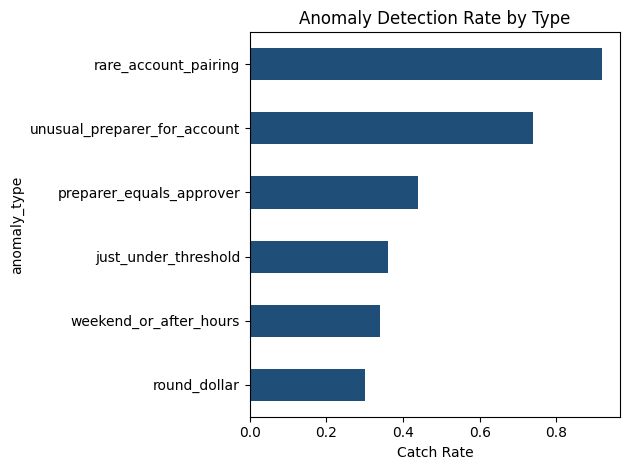

<Figure size 640x480 with 0 Axes>

In [87]:
import matplotlib.pyplot as plt

# horizontal bar chart, one bar per anomaly type, showing what % of each type got caught
catch_rate_by_type.plot(kind='barh', color='#1F4E78')
plt.xlabel('Catch Rate')
plt.title('Anomaly Detection Rate by Type')

# without this, the first category in the series would end up at the bottom of the chart instead of the top -- matplotlib draws bar charts bottom-up by default
plt.gca().invert_yaxis()

plt.tight_layout()  # keeps labels from getting cut off at the edges
plt.show()

plt.savefig('catch_rate_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

**Stats vs Model**

After working through the project I asked the question could I do the same thing with stats and get a more precise


In [88]:
# Rule-based baseline: three simple IF-conditions covering the "single value looks weird" anomaly types, written as plain pandas logic instead of a trained model. The goal is to see how much of the model's performance a few manual rules alone could already achieve.

# Rule 1: round-dollar amounts -- flags entries that are an exact multiple of 1000
rule_round_dollar = (df['amount'] % 1000 == 0)

# Rule 2: weekend or after-hours postings -- flags entries outside normal business hours
rule_weekend_after_hours = (df['is_weekend'] == True) | (df['posting_hour'] < 6) | (df['posting_hour'] > 20)

# Rule 3: just-under-threshold amounts -- flags entries sitting suspiciously close to, but just below, the $10,000 approval threshold used when the data was generated
rule_just_under_threshold = (df['amount'] >= 9925) & (df['amount'] < 10000)

# an entry is flagged by the rules baseline if ANY of the three rules catch it
df['rule_flagged'] = rule_round_dollar | rule_weekend_after_hours | rule_just_under_threshold

# merge the rule-based flags in with the real answer key, same approach as before
rule_results = df[['entry_id', 'rule_flagged']].merge(answer_key, on='entry_id')

# same precision/recall math as the model, just against the rule-based flag column instead
rule_tp = ((rule_results['rule_flagged'] == True) & (rule_results['is_anomaly'] == True)).sum()
rule_fp = ((rule_results['rule_flagged'] == True) & (rule_results['is_anomaly'] == False)).sum()
rule_fn = ((rule_results['rule_flagged'] == False) & (rule_results['is_anomaly'] == True)).sum()

rule_precision = rule_tp / (rule_tp + rule_fp)
rule_recall = rule_tp / (rule_tp + rule_fn)

print(f"Rules baseline -- Precision: {rule_precision:.1%}, Recall: {rule_recall:.1%}")
print(f"IsolationForest -- Precision: {precision:.1%}, Recall: {recall:.1%}")

Rules baseline -- Precision: 100.0%, Recall: 50.0%
IsolationForest -- Precision: 51.7%, Recall: 51.7%


In [89]:
# rule_planted already has anomaly_type from the earlier merge -- no second merge needed
rule_catch_rate_by_type = rule_planted.groupby('anomaly_type')['rule_flagged'].mean().sort_values(ascending=False)

print("Rules baseline catch rate by type:")
print(rule_catch_rate_by_type)
print()
print("Model catch rate by type:")
print(catch_rate_by_type)

Rules baseline catch rate by type:
anomaly_type
just_under_threshold            1.0
round_dollar                    1.0
weekend_or_after_hours          1.0
preparer_equals_approver        0.0
rare_account_pairing            0.0
unusual_preparer_for_account    0.0
Name: rule_flagged, dtype: float64

Model catch rate by type:
anomaly_type
rare_account_pairing            0.92
unusual_preparer_for_account    0.74
preparer_equals_approver        0.44
just_under_threshold            0.36
weekend_or_after_hours          0.34
round_dollar                    0.30
Name: predicted_anomaly, dtype: float64
